In [38]:
import sys
sys.path.append("../")

# Force reload of modules to pick up the fix
if 'Classes.Persistence' in sys.modules:
    del sys.modules['Classes.Persistence']
if 'Classes.Solution' in sys.modules:
    del sys.modules['Classes.Solution']
if 'Classes.Problem' in sys.modules:
    del sys.modules['Classes.Problem']
if 'Classes.Convergence' in sys.modules:
    del sys.modules['Classes.Convergence']
if 'Classes.Log' in sys.modules:
    del sys.modules['Classes.Log']

from Classes.Solution import Solution
from Classes.Persistence import PersistMultipleSolutions, PersistSingleSolution
from Classes.utils import boxplot_fx, boxplot_convergence, get_fx_samples
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np

ils = PersistMultipleSolutions().load(filename="ils_1600", filepath="./ils/results/")
vns = PersistMultipleSolutions().load(filename="vns_1600", filepath="./vns/results/")
ga = PersistMultipleSolutions().load(filename="ga_1600", filepath="./ga/results/")
optimum = PersistSingleSolution().load(filename="globopt_1600", filepath="./global_optimum/results/")

ils = ils[2]
vns = vns[0]
ga = ga[2]
solutions = [ils, vns, ga]
names = ["ILS", "VNS", "GA"]

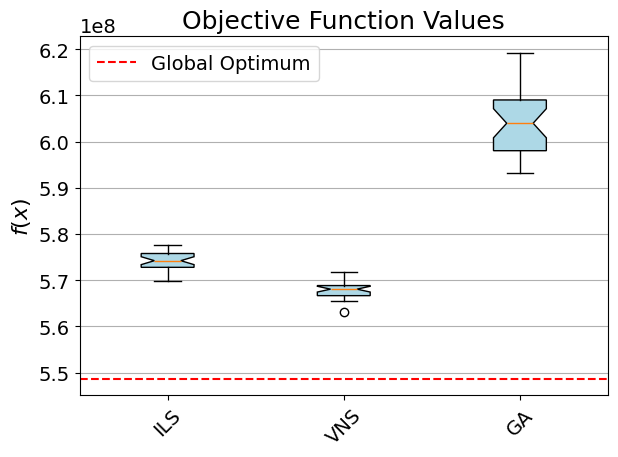

In [39]:
boxplot_fx(solutions, names, global_optimum=optimum)

In [40]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
fx = get_fx_samples(solutions)
alpha = 0.05

# Compare VNS vs ILS
print("=" * 50)
print("COMPARISON: VNS (Algorithm 2) vs ILS (Algorithm 1)")
print("=" * 50)
fx_comparison = [fx[1], fx[0]]  # VNS vs ILS

# Test for normality
print("\nShapiro-Wilk Test p-values:")
p_values = []
for i, name in enumerate(["VNS", "ILS"]):
    stat, p = shapiro(fx_comparison[i])
    p_values.append(p)
    print(f"{name}: {p:.4e}")

both_normal = all(p > alpha for p in p_values)
print(f"\nBoth samples normally distributed: {both_normal}")

# Choose appropriate test
if both_normal:
    print("\nUsing parametric t-test:")
    stat, p = ttest_ind(fx_comparison[0], fx_comparison[1], equal_var=False, alternative='less')
    print(f"T-test p-value: {p:.4e}")
else:
    print("\nUsing non-parametric Mann-Whitney U test:")
    stat, p = mannwhitneyu(fx_comparison[0], fx_comparison[1], alternative='less')
    print(f"Mann-Whitney U test p-value: {p:.4e}")

if p < alpha:
    print("✓ Result: VNS is significantly better than ILS (p < 0.05)")
else:
    print("✗ Result: No significant difference between VNS and ILS (p >= 0.05)")

# Compare VNS vs GA
print("\n" + "=" * 50)
print("COMPARISON: VNS (Algorithm 2) vs GA (Algorithm 3)")
print("=" * 50)
fx_comparison = [fx[1], fx[2]]  # VNS vs GA

# Test for normality
print("\nShapiro-Wilk Test p-values:")
p_values = []
for i, name in enumerate(["VNS", "GA"]):
    stat, p = shapiro(fx_comparison[i])
    p_values.append(p)
    print(f"{name}: {p:.4e}")

both_normal = all(p > alpha for p in p_values)
print(f"\nBoth samples normally distributed: {both_normal}")

# Choose appropriate test
if both_normal:
    print("\nUsing parametric t-test:")
    stat, p = ttest_ind(fx_comparison[0], fx_comparison[1], equal_var=False, alternative='less')
    print(f"T-test p-value: {p:.4e}")
else:
    print("\nUsing non-parametric Mann-Whitney U test:")
    stat, p = mannwhitneyu(fx_comparison[0], fx_comparison[1], alternative='less')
    print(f"Mann-Whitney U test p-value: {p:.4e}")

if p < alpha:
    print("✓ Result: VNS is significantly better than GA (p < 0.05)")
else:
    print("✗ Result: No significant difference between VNS and GA (p >= 0.05)")

COMPARISON: VNS (Algorithm 2) vs ILS (Algorithm 1)

Shapiro-Wilk Test p-values:
VNS: 3.5561e-01
ILS: 1.9135e-01

Both samples normally distributed: True

Using parametric t-test:
T-test p-value: 1.3765e-17
✓ Result: VNS is significantly better than ILS (p < 0.05)

COMPARISON: VNS (Algorithm 2) vs GA (Algorithm 3)

Shapiro-Wilk Test p-values:
VNS: 3.5561e-01
GA: 1.2685e-01

Both samples normally distributed: True

Using parametric t-test:
T-test p-value: 5.9653e-23
✓ Result: VNS is significantly better than GA (p < 0.05)


In [41]:
# Calculate Gurobi optimum and averages for each algorithm
gurobi_value = optimum.FX
vns_avg = np.mean(fx[1])
ils_avg = np.mean(fx[0])
ga_avg = np.mean(fx[2])

print("\n" + "=" * 50)
print("OBJECTIVE FUNCTION VALUES")
print("=" * 50)
print(f"Gurobi (Optimum):     {gurobi_value:.2e}")
print(f"VNS (Average):        {vns_avg:.2e}")
print(f"ILS (Average):        {ils_avg:.2e}")
print(f"GA (Average):         {ga_avg:.2e}")

# Calculate gaps to optimum
vns_gap = ((vns_avg - gurobi_value) / gurobi_value) * 100
ils_gap = ((ils_avg - gurobi_value) / gurobi_value) * 100
ga_gap = ((ga_avg - gurobi_value) / gurobi_value) * 100

print("\n" + "=" * 50)
print("GAP TO OPTIMUM (%)")
print("=" * 50)
print(f"VNS Gap:              {vns_gap:.2f}%")
print(f"ILS Gap:              {ils_gap:.2f}%")
print(f"GA Gap:               {ga_gap:.2f}%")


OBJECTIVE FUNCTION VALUES
Gurobi (Optimum):     5.49e+08
VNS (Average):        5.68e+08
ILS (Average):        5.74e+08
GA (Average):         6.04e+08

GAP TO OPTIMUM (%)
VNS Gap:              3.50%
ILS Gap:              4.65%
GA Gap:               10.13%


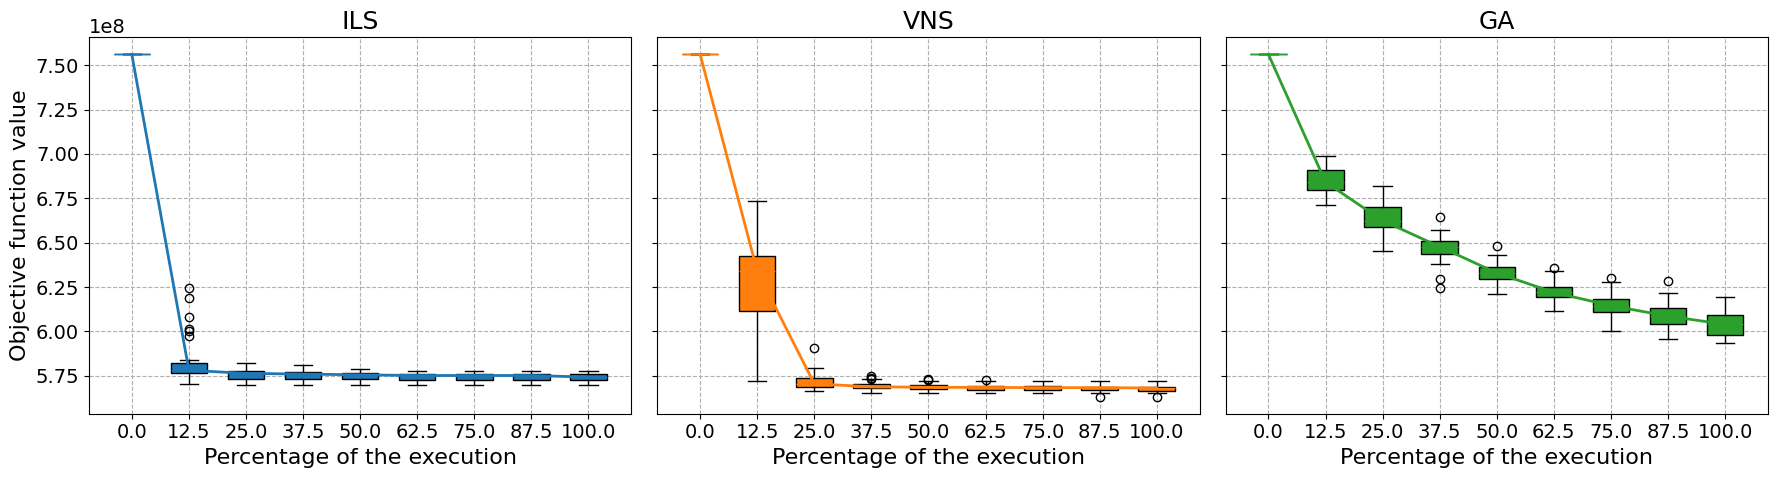

In [42]:
boxplot_convergence(solutions, names)